# Plot moisture convergence mean 

Plotting mean variable: moist_conv_daily_composite_mean_MJJAS
Long name: Moisture convergence
Units: mm/day
Color range:
vmin = -5.353693853082943
vmax = 5.353693853082943


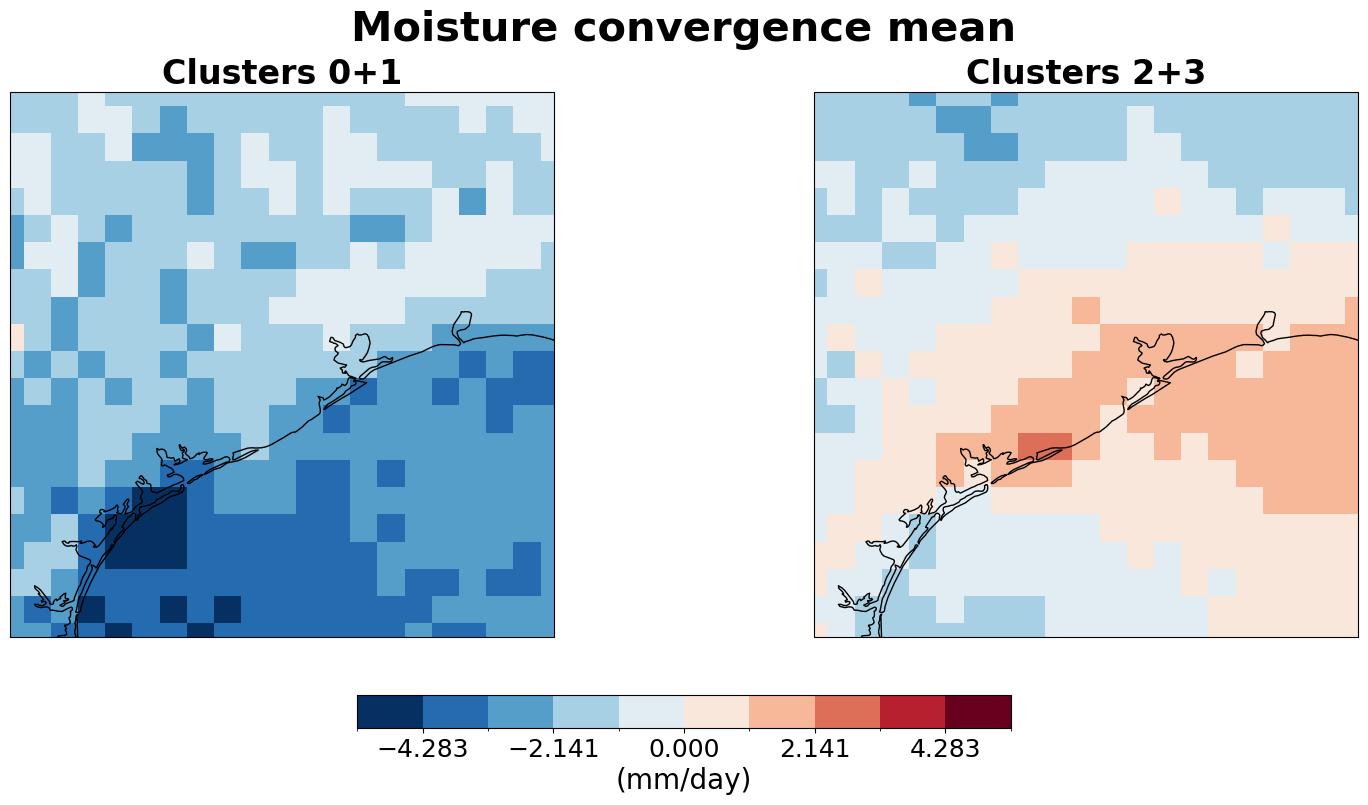

Saved: moisture_convergence_mean_clusters_01_23.png


In [3]:
# -*- coding: utf-8 -*-
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ----------------------------
# Config
# ----------------------------
FILE_FMT_MEAN = "composite_mean_terms_MJJAS_1998_2024_cluster_{c}.nc"

GROUPS = {
    "01": [0, 1],
    "23": [2, 3]
}

LAT_MIN, LAT_MAX = 27.0, 32.0
LON_MIN_W, LON_MAX_W = -98.0, -93.0

BASE_VAR = "moist_conv"

OUTFILE = "moisture_convergence_mean_clusters_01_23.png"

plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 26,
    "axes.labelsize": 26,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "figure.titlesize": 30,
})

# ----------------------------
# Helpers
# ----------------------------
def lat_name(ds):
    for k in ("latitude", "lat", "y"):
        if k in ds.coords or k in ds.dims:
            return k
    raise KeyError("No latitude name found.")

def lon_name(ds):
    for k in ("longitude", "lon", "x"):
        if k in ds.coords or k in ds.dims:
            return k
    raise KeyError("No longitude name found.")

def subset_bbox(da, lonn, latn, lon_min_w, lon_max_w, lat_min, lat_max):
    lon = da[lonn]
    lat = da[latn]

    # Handle 0-360 vs -180-180 longitudes
    if float(lon.max()) > 180.0:
        lon_min = (lon_min_w + 360.0) % 360.0
        lon_max = (lon_max_w + 360.0) % 360.0
    else:
        lon_min, lon_max = lon_min_w, lon_max_w

    if lon.ndim == 1 and lat.ndim == 1:
        def make_slice(arr, vmin, vmax):
            a0, a1 = float(arr[0]), float(arr[-1])
            lo, hi = sorted([vmin, vmax])
            return slice(lo, hi) if a0 <= a1 else slice(hi, lo)

        return da.sel({
            lonn: make_slice(lon, lon_min, lon_max),
            latn: make_slice(lat, lat_min, lat_max)
        })

    else:
        return da.where(
            (lon >= min(lon_min, lon_max)) &
            (lon <= max(lon_min, lon_max)) &
            (lat >= min(lat_min, lat_max)) &
            (lat <= max(lat_min, lat_max)),
            drop=True
        )

def combine_mean(arrays):
    aligned = xr.align(*arrays, join="inner")
    return xr.concat(aligned, dim="combine").mean("combine", skipna=True)

def safe_minmax(arrs):
    vmin = min([float(a.min(skipna=True)) for a in arrs])
    vmax = max([float(a.max(skipna=True)) for a in arrs])
    return vmin, vmax

def clean_long_name(ln, fallback):
    if not ln:
        return fallback
    return ln.split("(")[0].strip()

def plot_fill(ax, da, lonn, latn, subtitle, vmin, vmax, cmap):
    levels = np.linspace(vmin, vmax, 11)
    norm = BoundaryNorm(levels, cmap.N)

    ax.set_extent(
        [LON_MIN_W, LON_MAX_W, LAT_MIN, LAT_MAX],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)

    da.plot(
        ax=ax,
        x=lonn,
        y=latn,
        add_colorbar=False,
        cmap=cmap,
        levels=levels,
        norm=norm
    )

    ax.set_title(subtitle, fontsize=24, weight="bold")

    return cmap, norm, levels

# ----------------------------
# Identify mean moisture convergence variable
# ----------------------------
probe_mean = xr.open_dataset(FILE_FMT_MEAN.format(c=0))

latn = lat_name(probe_mean)
lonn = lon_name(probe_mean)

mean_var_map = {}

for v in probe_mean.data_vars:
    base = v.replace("_composite_mean_MJJAS", "").replace("_daily", "")
    mean_var_map[base] = v

if BASE_VAR not in mean_var_map:
    raise KeyError(
        f"Could not find {BASE_VAR} in mean file. "
        f"Available base variables are: {list(mean_var_map.keys())}"
    )

mean_var = mean_var_map[BASE_VAR]

sample = probe_mean[mean_var]
units = sample.attrs.get("units", "")
longname = clean_long_name(sample.attrs.get("long_name", BASE_VAR), BASE_VAR)

probe_mean.close()

print("Plotting mean variable:", mean_var)
print("Long name:", longname)
print("Units:", units)

# ----------------------------
# Load cluster mean files
# ----------------------------
mean_ds = {
    c: xr.open_dataset(FILE_FMT_MEAN.format(c=c))
    for c in [0, 1, 2, 3]
}

# ----------------------------
# Build grouped mean composites
# ----------------------------
mean_groups = {}

for tag, cl in GROUPS.items():
    mean_groups[tag] = combine_mean([
        mean_ds[c][mean_var] for c in cl
    ])

    mean_groups[tag] = subset_bbox(
        mean_groups[tag],
        lonn,
        latn,
        LON_MIN_W,
        LON_MAX_W,
        LAT_MIN,
        LAT_MAX
    )

# ----------------------------
# Color range for mean moisture convergence
# ----------------------------
raw_vmin_mean, raw_vmax_mean = safe_minmax([
    mean_groups["01"],
    mean_groups["23"]
])

# Moisture convergence may have positive and negative values.
# Use a symmetric diverging color scale if it crosses zero.
if raw_vmin_mean < 0.0 and raw_vmax_mean > 0.0:
    max_abs = max(abs(raw_vmin_mean), abs(raw_vmax_mean))
    vmin_mean = -max_abs
    vmax_mean = max_abs
    cmap_mean = plt.get_cmap("RdBu_r", 10)
else:
    vmin_mean = raw_vmin_mean
    vmax_mean = raw_vmax_mean
    cmap_mean = plt.get_cmap("Blues", 10)

print("Color range:")
print("vmin =", vmin_mean)
print("vmax =", vmax_mean)

# ----------------------------
# Plot mean moisture convergence
# ----------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

fig.suptitle("Moisture convergence mean", fontsize=30, weight="bold")

cmapM, normM, levM = plot_fill(
    axes[0],
    mean_groups["01"],
    lonn,
    latn,
    "Clusters 0+1",
    vmin_mean,
    vmax_mean,
    cmap_mean
)

plot_fill(
    axes[1],
    mean_groups["23"],
    lonn,
    latn,
    "Clusters 2+3",
    vmin_mean,
    vmax_mean,
    cmap_mean
)

smM = plt.cm.ScalarMappable(norm=normM, cmap=cmapM)

cbar = fig.colorbar(
    smM,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.1
)

if units:
    cbar.set_label(f"({units})", fontsize=20)
else:
    cbar.set_label("Moisture convergence", fontsize=20)

cbar.ax.tick_params(labelsize=18)

fig.savefig(OUTFILE, dpi=300)
plt.show()

print(f"Saved: {OUTFILE}")

# ----------------------------
# Cleanup
# ----------------------------
for c in [0, 1, 2, 3]:
    mean_ds[c].close()